# Movie Success Prediction: Machine Learning Module

This notebook extends the Step 1 analysis from describing movie success factors to predicting whether a movie is successful from an audience-response perspective.

The target label is:

`success_movie = 1` if `vote_average >= 7.0` and `vote_count >= 50`, otherwise `0`.

This is a classification task. It does not implement a recommendation system or any LLM-related feature.

# 1. Objective and Scope

**Research question:** Can metadata features help predict whether a movie is successful from the audience perspective?

The model uses cleaned Step 1 metadata and selected features available in `cleaned_movies.csv`: budget, runtime, popularity, release year, original language, and main genre. `vote_average` and `vote_count` define the target label, so they are intentionally excluded from model features to avoid data leakage.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling import (
    MODEL_FEATURES,
    TARGET_COLUMN,
    create_success_dataset,
    load_cleaned_movies,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_model_comparison,
    random_forest_feature_importance,
    save_metrics,
    save_models,
    split_features,
    train_and_evaluate_models,
)

CLEANED_PATH = PROJECT_ROOT / "outputs" / "cleaned_movies.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
METRICS_PATH = OUTPUT_DIR / "ml_model_metrics.csv"
SUMMARY_PATH = OUTPUT_DIR / "ml_success_prediction_summary.md"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

cleaned_movies = load_cleaned_movies(CLEANED_PATH)
print(cleaned_movies.shape)
cleaned_movies[MODEL_FEATURES + ["vote_average", "vote_count"]].head()

(45433, 32)


,budget,runtime,popularity,release_year,original_language,main_genre,vote_average,vote_count
0,30000000,81.0,21.946943,1995.0,en,Animation,7.7,5415.0
1,65000000,104.0,17.015539,1995.0,en,Adventure,6.9,2413.0
2,0,101.0,11.712900,1995.0,en,Romance,6.5,92.0
3,16000000,127.0,3.859495,1995.0,en,Comedy,6.1,34.0
4,0,106.0,8.387519,1995.0,en,Comedy,5.7,173.0


# 2. Label Definition

**Research question:** How should audience-level movie success be defined for the first machine learning version?

For this project stage, a successful movie is defined as one that has both a high audience rating and enough votes to make the rating more reliable. The threshold is intentionally simple and explainable for a university presentation.

In [2]:
model_df, label_summary = create_success_dataset(
    cleaned_movies,
    rating_threshold=7.0,
    vote_count_threshold=50,
)

label_summary_table = pd.DataFrame([
    ("Rows before ML filtering", f"{label_summary['initial_rows']:,}"),
    ("Rows used for modeling", f"{label_summary['model_rows']:,}"),
    ("Successful movies", f"{label_summary['positive_rows']:,}"),
    ("Non-successful movies", f"{label_summary['negative_rows']:,}"),
    ("Positive class rate", f"{label_summary['positive_rate']:.2%}"),
    ("Rating threshold", label_summary["rating_threshold"]),
    ("Vote-count threshold", label_summary["vote_count_threshold"]),
], columns=["Item", "Value"])
label_summary_table

,Item,Value
0,Rows before ML filtering,"45,433"
1,Rows used for modeling,"45,349"
2,Successful movies,"2,502"
3,Non-successful movies,"42,847"
4,Positive class rate,5.52%
5,Rating threshold,7.0
6,Vote-count threshold,50


In [3]:
label_distribution = model_df[TARGET_COLUMN].value_counts().rename(index={0: "Not success", 1: "Success"}).reset_index()
label_distribution.columns = ["Class", "Movie count"]
label_distribution

,Class,Movie count
0,Not success,42847
1,Success,2502


**Short interpretation:** The target is audience-focused, not financial. A movie can be commercially successful but not meet this audience-success label, and vice versa. This keeps the first ML task clear and avoids mixing different definitions of success.

# 3. Feature Selection and Preprocessing

**Research question:** Which metadata features can be used without leaking the target label?

Selected features:

- `budget`
- `runtime`
- `popularity`
- `release_year`
- `original_language`
- `main_genre`

Preprocessing decisions:

- Missing numeric values are imputed with the median.
- Missing categorical values are imputed with the most frequent category or `Unknown`.
- Categorical variables are one-hot encoded.
- Budget values less than or equal to zero are treated as missing, not as true zero budget.
- Runtime values less than or equal to zero or above 300 minutes are treated as missing.
- Numeric outliers are capped using quantiles before modeling.

`vote_average` and `vote_count` are excluded from the feature set because they define the label.

In [4]:
feature_missing = model_df[MODEL_FEATURES].isna().sum().reset_index()
feature_missing.columns = ["Feature", "Missing rows after ML cleaning"]
feature_missing

,Feature,Missing rows after ML cleaning
0,budget,36469
1,runtime,1923
2,popularity,0
3,release_year,84
4,original_language,0
5,main_genre,0


In [5]:
model_df[MODEL_FEATURES + [TARGET_COLUMN]].head()

,budget,runtime,popularity,release_year,original_language,main_genre,success_movie
0,30000000.0,81.0,17.018056,1995.0,en,Animation,1
1,65000000.0,104.0,17.015539,1995.0,en,Adventure,0
2,NaN,101.0,11.712900,1995.0,en,Romance,0
3,16000000.0,127.0,3.859495,1995.0,en,Comedy,0
4,NaN,106.0,8.387519,1995.0,en,Comedy,0


# 4. Train/Test Split

**Research question:** How can the model be evaluated on unseen data?

The dataset is split into training and testing sets using stratification so that both classes keep a similar proportion in each split.

In [6]:
X_train, X_test, y_train, y_test = split_features(model_df, test_size=0.2, random_state=42)

split_summary = pd.DataFrame([
    ("Training rows", f"{len(X_train):,}"),
    ("Test rows", f"{len(X_test):,}"),
    ("Training positive rate", f"{y_train.mean():.2%}"),
    ("Test positive rate", f"{y_test.mean():.2%}"),
], columns=["Item", "Value"])
split_summary

,Item,Value
0,Training rows,"36,279"
1,Test rows,"9,070"
2,Training positive rate,5.52%
3,Test positive rate,5.51%


# 5. Model Training

**Research question:** Which baseline classification models are useful for this project stage?

Two models are trained:

1. **Logistic Regression**: interpretable linear baseline.
2. **Random Forest**: non-linear tree-based model that can capture interactions between metadata features.

Both models use class balancing because successful movies are less common than non-successful movies under the chosen label definition.

In [7]:
models, metrics_df, model_details = train_and_evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test,
    random_state=42,
)

save_metrics(metrics_df, METRICS_PATH)
model_paths = save_models(models, MODELS_DIR)
metrics_df

,model,accuracy,precision,recall,f1
1,Random Forest,0.908049,0.348457,0.768,0.479401
0,Logistic Regression,0.852811,0.250448,0.838,0.385642


# 6. Model Evaluation

**Research question:** How well do the models predict successful movies?

The notebook evaluates accuracy, precision, recall, F1-score, and confusion matrix. F1-score is useful here because the positive class is smaller than the negative class.

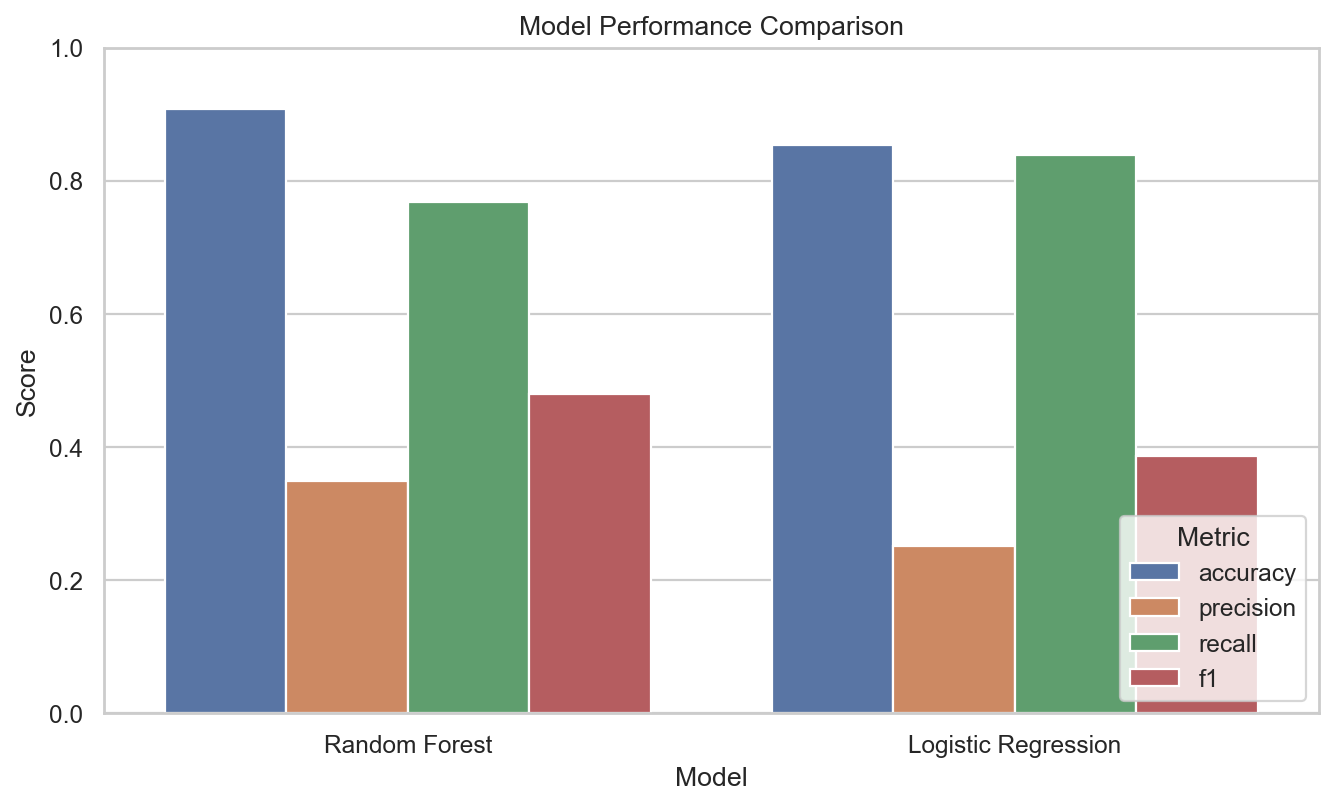

In [8]:
comparison_path = plot_model_comparison(metrics_df, FIGURES_DIR / "ml_model_comparison.png")
display(Image(filename=str(comparison_path)))

Best model by F1-score: Random Forest


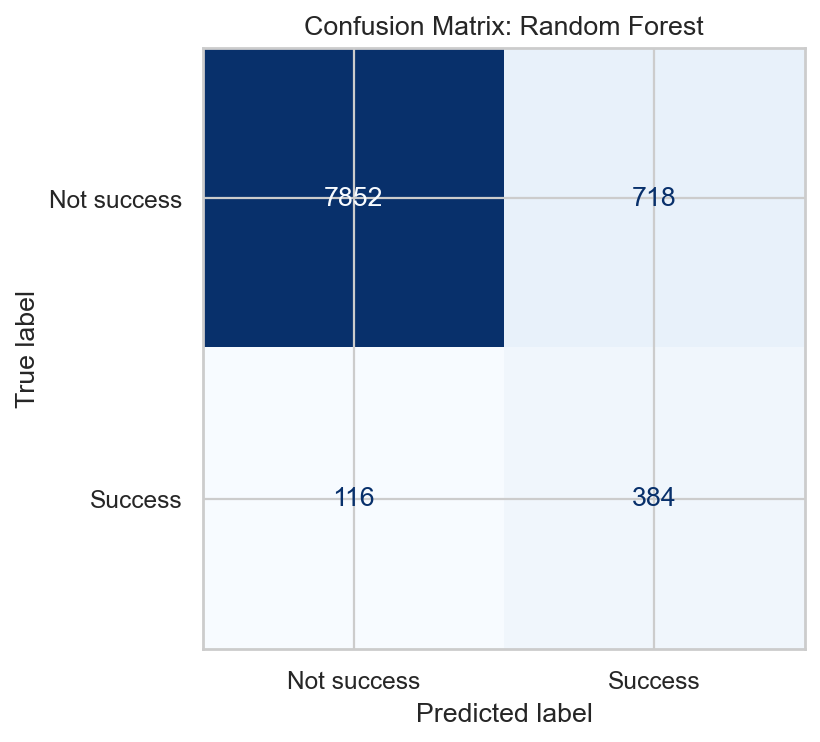

In [9]:
best_model_name = metrics_df.iloc[0]["model"]
best_matrix = model_details[best_model_name]["confusion_matrix"]
confusion_path = plot_confusion_matrix(
    best_matrix,
    best_model_name,
    FIGURES_DIR / "ml_confusion_matrix.png",
)
print(f"Best model by F1-score: {best_model_name}")
display(Image(filename=str(confusion_path)))

**Short interpretation:** Accuracy alone is not enough for this task because the successful class is smaller. Precision, recall, and F1-score give a clearer view of whether the model is identifying successful movies or mostly predicting the majority class.

# 7. Feature Importance

**Research question:** Which factors most influence the prediction of audience-level success?

Random Forest feature importance is used as an interpretable indicator of which features contribute more strongly to the model. It should be read as model-based importance, not as causal proof.

,feature,importance
0,popularity,0.620797
1,runtime,0.127467
2,budget,0.082595
3,release_year,0.060566
4,main_genre_Unknown,0.013422
5,original_language_en,0.009764
6,main_genre_Animation,0.007859
7,main_genre_Horror,0.007613
8,main_genre_Comedy,0.007403
9,main_genre_Documentary,0.007299


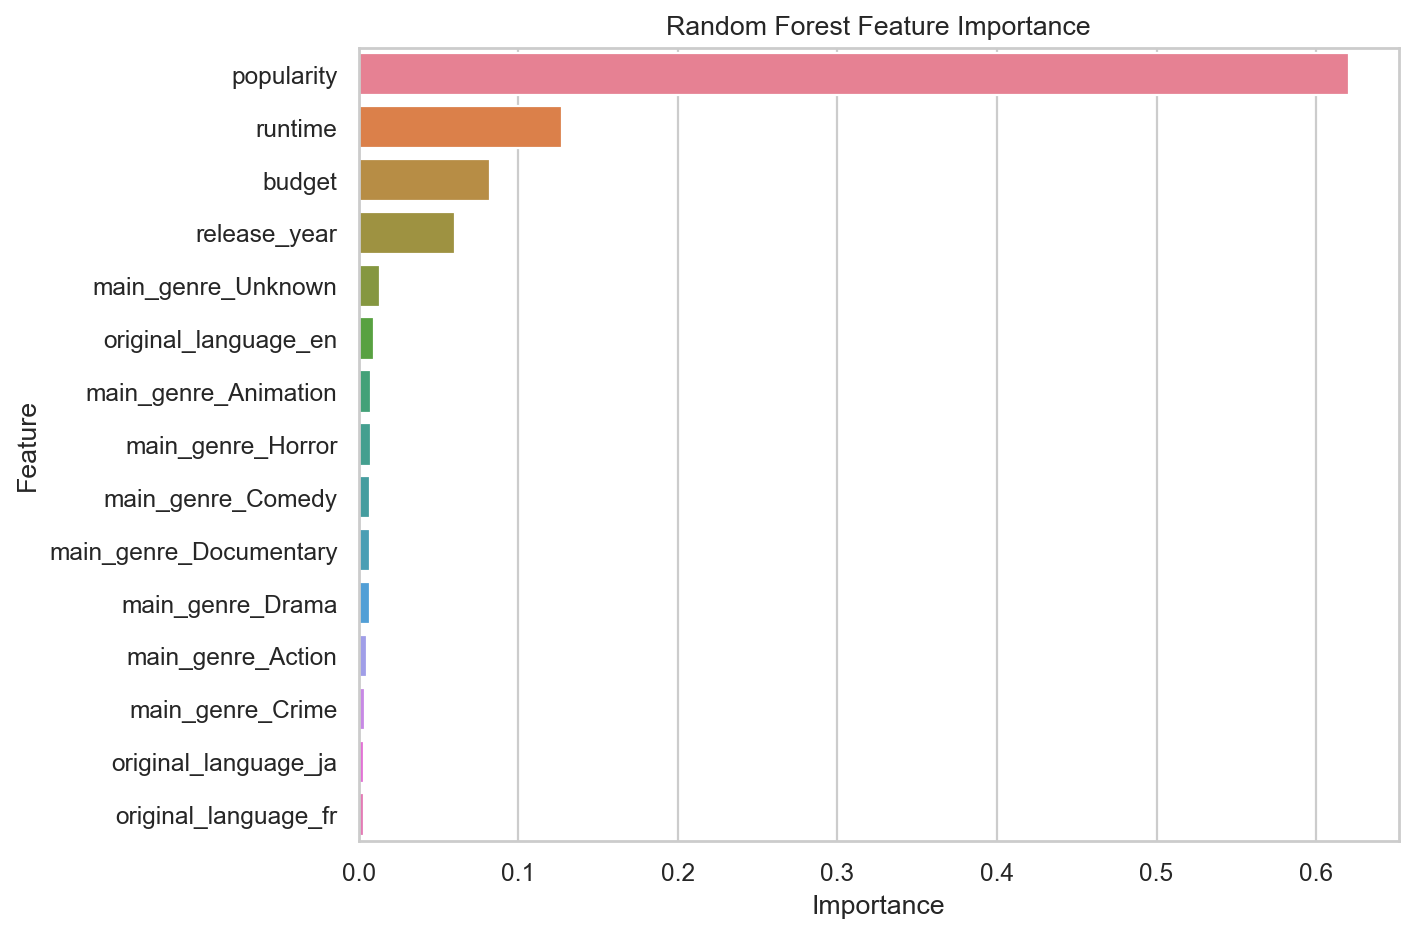

In [10]:
rf_importance = random_forest_feature_importance(models["Random Forest"], top_n=15)
importance_path = plot_feature_importance(rf_importance, FIGURES_DIR / "ml_feature_importance.png")
display(rf_importance)
display(Image(filename=str(importance_path)))

**Short interpretation:** Feature importance helps connect the ML module back to the Step 1 EDA theme. It shows which metadata variables the model uses most for prediction, but it does not prove that those variables cause movie success.

# 8. Main Findings

This first ML module should be treated as a baseline success-prediction model. It is useful for showing that the project can move from descriptive analysis to predictive analysis, while still keeping the target definition transparent.

In [11]:
best_metrics = metrics_df.iloc[0]
top_features = rf_importance.head(5)["feature"].tolist()

findings = [
    f"1. The target label defines audience-level success as vote_average >= 7.0 and vote_count >= 50.",
    f"2. The best model by F1-score is {best_model_name}, with accuracy {best_metrics['accuracy']:.3f}, precision {best_metrics['precision']:.3f}, recall {best_metrics['recall']:.3f}, and F1-score {best_metrics['f1']:.3f}.",
    f"3. The top Random Forest features are: {', '.join(top_features)}.",
    "4. The model uses metadata features only and avoids vote_average/vote_count leakage.",
]

display(Markdown("\n".join(findings)))

1. The target label defines audience-level success as vote_average >= 7.0 and vote_count >= 50.
2. The best model by F1-score is Random Forest, with accuracy 0.908, precision 0.348, recall 0.768, and F1-score 0.479.
3. The top Random Forest features are: popularity, runtime, budget, release_year, main_genre_Unknown.
4. The model uses metadata features only and avoids vote_average/vote_count leakage.

# 9. Limitations and Future Work

**Limitations**

- The target label is audience-focused and does not directly measure revenue or ROI.
- `success_movie` depends on thresholds chosen for this project stage.
- Budget has many missing or invalid values, so imputation is required.
- `main_genre` simplifies multi-genre movies to one category.
- Feature importance is model-based, not causal evidence.

**Future work**

- Test alternative success labels, such as financial success or combined commercial/audience success.
- Tune model hyperparameters with cross-validation.
- Add credits, keywords, and ratings files in later stages.
- Compare additional models after the baseline module is accepted.

In [12]:
metrics_text = metrics_df.round(3).to_string(index=False)

summary_md = f'''# Movie Success Prediction: ML Module Summary

## Objective

This machine learning module extends the Step 1 EDA from describing movie success factors to predicting whether a movie is successful from an audience-response perspective.

## Target Definition

A movie is labeled as `success_movie = 1` when `vote_average >= 7.0` and `vote_count >= 50`; otherwise it is labeled `0`.

## Dataset

- Source file: `outputs/cleaned_movies.csv`
- Rows used for modeling: {label_summary['model_rows']:,}
- Successful movies: {label_summary['positive_rows']:,}
- Non-successful movies: {label_summary['negative_rows']:,}
- Positive class rate: {label_summary['positive_rate']:.2%}

## Features

The model uses: {', '.join(MODEL_FEATURES)}.

`vote_average` and `vote_count` are excluded from the feature set because they define the target label and would create data leakage.

## Models

- Logistic Regression
- Random Forest

Both models use class balancing to reduce the effect of class imbalance.

## Evaluation Results

```text
{metrics_text}
```

Best model by F1-score: **{best_model_name}**.

## Feature Importance

Top Random Forest features: {', '.join(top_features)}.

Feature importance should be interpreted as model-based importance, not causal proof.

## Generated Outputs

- `outputs/ml_model_metrics.csv`
- `outputs/models/logistic_regression.joblib`
- `outputs/models/random_forest.joblib`
- `outputs/figures/ml_model_comparison.png`
- `outputs/figures/ml_confusion_matrix.png`
- `outputs/figures/ml_feature_importance.png`

## Limitations

- The label captures audience success, not direct financial success.
- Threshold choices affect the label distribution.
- Budget and some metadata features require imputation.
- `main_genre` simplifies multi-genre movies.
- More models and cross-validation can be added later.
'''

SUMMARY_PATH.write_text(summary_md, encoding="utf-8")

checklist = pd.DataFrame([
    ("ML summary generated", SUMMARY_PATH.exists(), str(SUMMARY_PATH.relative_to(PROJECT_ROOT))),
    ("Metrics CSV generated", METRICS_PATH.exists(), str(METRICS_PATH.relative_to(PROJECT_ROOT))),
    ("Model files generated", all(path.exists() for path in model_paths.values()), ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in model_paths.values())),
    ("Evaluation figures generated", all((FIGURES_DIR / name).exists() for name in ["ml_model_comparison.png", "ml_confusion_matrix.png", "ml_feature_importance.png"]), "3 ML figures"),
    ("No label leakage", True, "vote_average and vote_count excluded from model features"),
], columns=["Check", "Passed", "Details"])

print("Final ML checklist")
display(checklist)
print(f"Summary written to: {SUMMARY_PATH}")

Final ML checklist


,Check,Passed,Details
0,ML summary generated,True,outputs\ml_success_prediction_summary.md
1,Metrics CSV generated,True,outputs\ml_model_metrics.csv
2,Model files generated,True,"outputs\models\logistic_regression.joblib, out..."
3,Evaluation figures generated,True,3 ML figures
4,No label leakage,True,vote_average and vote_count excluded from mode...


Summary written to: C:\Users\刘子豪\Desktop\code\IMDB_analysis\outputs\ml_success_prediction_summary.md
